In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "/Users/dougs/Annapurna Dropbox/Doug Sack/Interactive/IndieBI/sales_curve_data/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.xlsx")

# Read all files into DataFrames and add filename column
dfs = [pd.read_excel(file, skiprows=2).assign(Source=os.path.basename(file)) for file in files]




In [3]:
df = pd.concat(dfs, ignore_index=True)


In [4]:
df.head()

,Date,product,Cumulative Selected Measure,Source
0,2018-03-13,Florence,356,google.xlsx
1,2018-03-14,Florence,2720,google.xlsx
2,2018-03-15,Florence,4017,google.xlsx
3,2018-03-16,Florence,4655,google.xlsx
4,2018-03-17,Florence,5074,google.xlsx


In [5]:
df.Source.unique()

array(['google.xlsx', 'nintendo.xlsx', 'playstation.xlsx', 'epic.xlsx',
       'gog.xlsx', 'steam.xlsx', 'xbox.xlsx', 'apple.xlsx', 'humble.xlsx'],
      dtype=object)

In [6]:
file_name = 'xbox'

In [7]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"
dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [8]:
df_combined = df.query(f"Source =='{file_name}.xlsx'")
#df_combined['release_date'] = df_combined['product'].map(release_dict)

In [9]:
release_date_dict

{'A Memoir Blue': Timestamp('2022-03-24 00:00:00'),
 'Ashen': Timestamp('2019-12-09 00:00:00'),
 'BattleSage': Timestamp('2025-06-30 00:00:00'),
 'Cocoon': Timestamp('2023-09-29 00:00:00'),
 'Donut County': Timestamp('2018-08-28 00:00:00'),
 'Due Process': Timestamp('2020-11-03 00:00:00'),
 'Faraway': Timestamp('2025-12-31 00:00:00'),
 'Flock': Timestamp('2024-07-16 00:00:00'),
 'Florence': Timestamp('2020-02-13 00:00:00'),
 'Flower': Timestamp('2019-02-14 00:00:00'),
 'Gorogoa': Timestamp('2017-12-14 00:00:00'),
 'Hindsight': Timestamp('2022-08-04 00:00:00'),
 'Hohokum': Timestamp('2022-07-28 00:00:00'),
 'I Am Dead': Timestamp('2020-10-08 00:00:00'),
 'If Found...': Timestamp('2020-05-19 00:00:00'),
 'Journey': Timestamp('2020-06-11 00:00:00'),
 'Kentucky Route Zero: TV Edition': Timestamp('2020-01-28 00:00:00'),
 'Last Stop': Timestamp('2021-07-22 00:00:00'),
 'Lorelei and the Laser Eyes': Timestamp('2024-05-16 00:00:00'),
 'Lushfoil Photography Sim': Timestamp('2025-04-15 00:00:00'

In [10]:
dates.sort_values(by='product')

,product,pc_release_date
21,A Memoir Blue,2022-03-24
38,Ashen,2019-12-09
4,BattleSage,2025-06-30
14,Cocoon,2023-09-29
41,Donut County,2018-08-28
29,Due Process,2020-11-03
0,Faraway,2025-12-31
10,Flock,2024-07-16
35,Florence,2020-02-13
40,Flower,2019-02-14


In [11]:
df_combined

,Date,product,Cumulative Selected Measure,Source
192836,2022-04-04,A Memoir Blue,7,xbox.xlsx
192837,2022-04-04,Ashen,5,xbox.xlsx
192838,2022-04-04,Ashen Definitive Edition,1,xbox.xlsx
192839,2022-04-04,Donut County,8,xbox.xlsx
192840,2022-04-04,I Am Dead,1,xbox.xlsx
...,...,...,...,...
218898,2025-06-11,Thirsty Suitors,336,xbox.xlsx
218899,2025-06-11,to a T,787,xbox.xlsx
218900,2025-06-11,Twelve Minutes,25675,xbox.xlsx
218901,2025-06-11,Wanderstop,2642,xbox.xlsx


In [12]:
df_combined['release_date'] = pd.to_datetime(df_combined['Date'])

In [13]:
df_combined['release_date'] = df_combined.groupby('product')['release_date'].transform('min')

In [14]:
df_combined["DAR"] = (df_combined["Date"] - df_combined["release_date"]).dt.days
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)

df_combined["Weeks_from_Release"] = (df_combined["DAR"] // 7) + 1  # Week 1 starts at 0-7 days

df_combined = df_combined.query("0 <= Weeks_from_Release <=156")

df_combined = df_combined.query("'1/1/2015' <= release_date <= '1/1/2024'")

df_combined = df_combined.groupby(["product", "Weeks_from_Release"], as_index=False)["Cumulative Selected Measure"].max()

In [15]:
title_exclusion = ['Ashen', 'Ashen - Nightstorm Isle DLC',
       'Ashen Definitive Edition',]

In [16]:
title_exclusion = [
'Stray','Outer Wilds','Ashen', 'Ashen - Nightstorm Isle DLC',
       'Ashen Definitive Edition', 'Outer Wilds - Archaeologist Edition BUNDLE',
       'Outer Wilds - Echoes of the Eye DLC','I Am Dead','Gorogoa','Last Stop','Telling Lies']

In [17]:
title_exclusion = [
'Stray','Outer Wilds','Outer Wilds - Echoes of the Eye DLC'
]

In [18]:
df_combined['product'].unique()

array(['A Memoir Blue', 'Ashen', 'Ashen - Nightstorm Isle DLC',
       'Ashen Definitive Edition', 'Cocoon', 'Donut County', 'Gorogoa',
       'Hindsight', 'I Am Dead', 'Kentucky Route Zero: TV Edition',
       'Last Stop', 'Maquette', 'Outer Wilds',
       'Outer Wilds - Archaeologist Edition BUNDLE',
       'Outer Wilds - Echoes of the Eye DLC', 'Sayonara Wild Hearts',
       'Solar Ash', 'Stray', 'Telling Lies', 'The Artful Escape',
       'The Pathless', 'Thirsty Suitors', 'Twelve Minutes',
       'What Remains of Edith Finch'], dtype=object)

In [19]:
df_combined

,product,Weeks_from_Release,Cumulative Selected Measure
0,A Memoir Blue,1,58
1,A Memoir Blue,2,91
2,A Memoir Blue,3,122
3,A Memoir Blue,4,137
4,A Memoir Blue,5,167
...,...,...,...
3364,What Remains of Edith Finch,152,75907
3365,What Remains of Edith Finch,153,76052
3366,What Remains of Edith Finch,154,76189
3367,What Remains of Edith Finch,155,76311


In [20]:
df_combined = df_combined.query("product !=@title_exclusion")

In [21]:
df_combined['product'].unique()

array(['A Memoir Blue', 'Ashen', 'Ashen - Nightstorm Isle DLC',
       'Ashen Definitive Edition', 'Cocoon', 'Donut County', 'Gorogoa',
       'Hindsight', 'I Am Dead', 'Kentucky Route Zero: TV Edition',
       'Last Stop', 'Maquette',
       'Outer Wilds - Archaeologist Edition BUNDLE',
       'Sayonara Wild Hearts', 'Solar Ash', 'Telling Lies',
       'The Artful Escape', 'The Pathless', 'Thirsty Suitors',
       'Twelve Minutes', 'What Remains of Edith Finch'], dtype=object)

## Xbox Smoothing

In [23]:
# Sort for safety
df_combined = df_combined.sort_values(['product', 'Weeks_from_Release'])

# Smooth cumulative values using rolling average (e.g., 3-week window)
df_combined['Cumulative Selected Measure'] = (
    df_combined
    .groupby('product')['Cumulative Selected Measure']
    .transform(lambda x: x.rolling(window=12, min_periods=1, center=True).mean())
)

In [24]:
df_combined["percent_of_max"] = df_combined["Cumulative Selected Measure"] / df_combined.groupby("product")["Cumulative Selected Measure"].transform("max")
#df_combined

In [25]:
#pd.set_option("display.max_rows", None)


df_combined["CUME_total"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].transform("max")
df_combined["prop_of_total"] = df_combined["Cumulative Selected Measure"] / df_combined["CUME_total"]
df_combined["daily_delta"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].pct_change().fillna(0)
df_combined.query("product=='Ashen' & Weeks_from_Release <=52")


,product,Weeks_from_Release,Cumulative Selected Measure,percent_of_max,CUME_total,prop_of_total,daily_delta
156,Ashen,1,186.333333,0.020551,9066.714286,0.020551,0.000000
157,Ashen,2,241.142857,0.026596,9066.714286,0.026596,0.294148
158,Ashen,3,284.000000,0.031323,9066.714286,0.031323,0.177725
159,Ashen,4,318.666667,0.035147,9066.714286,0.035147,0.122066
160,Ashen,5,348.100000,0.038393,9066.714286,0.038393,0.092364
161,Ashen,6,385.181818,0.042483,9066.714286,0.042483,0.106526
162,Ashen,7,438.666667,0.048382,9066.714286,0.048382,0.138856
163,Ashen,8,543.416667,0.059935,9066.714286,0.059935,0.238792
164,Ashen,9,648.916667,0.071571,9066.714286,0.071571,0.194142
165,Ashen,10,753.916667,0.083152,9066.714286,0.083152,0.161808


In [26]:
audit = df_combined.query("Weeks_from_Release <=52").pivot(index='product', columns='Weeks_from_Release',values='daily_delta').reset_index()
audit.sort_values(by=2,ascending=False)

Weeks_from_Release,product,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
13,Sayonara Wild Hearts,0.0,1.297959,0.546403,0.288219,0.185229,0.205898,0.239447,0.320023,0.241993,...,0.010451,0.006589,0.006387,0.006150,0.006465,0.006306,0.006074,0.005768,0.005467,0.005437
16,The Artful Escape,0.0,0.596210,0.311301,0.197644,0.136906,0.148325,0.168438,0.240160,0.192577,...,0.031605,0.030876,0.015695,0.014950,0.014369,0.013633,0.013187,0.012669,0.012126,0.011939
19,Twelve Minutes,0.0,0.364431,0.218269,0.151627,0.113646,0.119002,0.153640,0.237671,0.190234,...,0.022672,0.022053,0.020319,0.017963,0.032053,0.034174,0.033148,0.031326,0.029851,0.029155
3,Ashen Definitive Edition,0.0,0.317952,0.183151,0.122240,0.088756,0.129601,0.197414,0.312125,0.238726,...,0.013913,0.013722,0.013600,0.013423,0.013144,0.003681,0.000849,0.000909,0.000892,0.000929
10,Last Stop,0.0,0.307612,0.180622,0.122143,0.089607,0.552415,0.620358,0.572636,0.371945,...,0.004023,0.004192,0.003806,0.003792,0.003534,0.003643,0.003448,0.003497,0.003304,0.002994
12,Outer Wilds - Archaeologist Edition BUNDLE,0.0,0.294787,0.194111,0.147297,0.114302,0.114944,0.122276,0.202364,0.166949,...,0.060706,0.068151,0.053934,0.034760,0.027795,0.026494,0.025732,0.025406,0.024946,0.024472
1,Ashen,0.0,0.294148,0.177725,0.122066,0.092364,0.106526,0.138856,0.238792,0.194142,...,0.065743,0.052628,0.031207,0.007020,0.002018,0.002030,0.001644,0.001426,0.001407,0.001389
9,Kentucky Route Zero: TV Edition,0.0,0.210604,0.156022,0.114794,0.090308,0.140496,0.195652,0.266667,0.215789,...,0.029709,0.048803,0.066725,0.063100,0.064774,0.062288,0.062286,0.059708,0.057154,0.054448
2,Ashen - Nightstorm Isle DLC,0.0,0.197652,0.132353,0.111111,0.096364,0.103573,0.112022,0.185811,0.150997,...,0.099468,0.084068,0.066920,0.057312,0.036757,0.010995,0.001665,0.001662,0.001549,0.001877
5,Donut County,0.0,0.139675,0.487647,0.480460,0.293168,0.223661,0.207409,0.273308,0.215191,...,0.039029,0.040085,0.040857,0.040846,0.041514,0.041707,0.040462,0.037591,0.032999,0.046835


In [27]:
# Flatten the DataFrame and filter values > 5
filtered = audit.set_index('product').stack()
high_vals = filtered[filtered > 3]

# Sort descending to find the highest ones
top_high_vals = high_vals.sort_values(ascending=False)

top_high_vals.sort_index(level='product')

Series([], dtype: float64)

In [28]:
platform_df = df_combined.groupby("Weeks_from_Release")[['daily_delta','prop_of_total']].mean()
platform_df['platform'] = file_name

In [29]:
platform_df.query(" Weeks_from_Release <=52")

,daily_delta,prop_of_total,platform
Weeks_from_Release,,,
1,0.000000,0.037670,xbox
2,0.225106,0.040364,xbox
3,0.289294,0.043153,xbox
4,0.182564,0.045826,xbox
5,0.117121,0.048243,xbox
6,0.210136,0.051474,xbox
7,0.234906,0.055755,xbox
8,0.255523,0.063650,xbox
9,0.184384,0.071047,xbox


In [30]:
platform_df.to_csv(f"units/{file_name}_average.csv")

In [31]:
df_combined

,product,Weeks_from_Release,Cumulative Selected Measure,percent_of_max,CUME_total,prop_of_total,daily_delta
0,A Memoir Blue,1,129.166667,0.019586,6594.857143,0.019586,0.000000
1,A Memoir Blue,2,143.142857,0.021705,6594.857143,0.021705,0.108203
2,A Memoir Blue,3,156.375000,0.023712,6594.857143,0.023712,0.092440
3,A Memoir Blue,4,169.444444,0.025693,6594.857143,0.025693,0.083578
4,A Memoir Blue,5,182.500000,0.027673,6594.857143,0.027673,0.077049
...,...,...,...,...,...,...,...
3364,What Remains of Edith Finch,152,75688.181818,0.995377,76039.714286,0.995377,0.001270
3365,What Remains of Edith Finch,153,75781.100000,0.996599,76039.714286,0.996599,0.001228
3366,What Remains of Edith Finch,154,75870.888889,0.997780,76039.714286,0.997780,0.001185
3367,What Remains of Edith Finch,155,75956.375000,0.998904,76039.714286,0.998904,0.001127


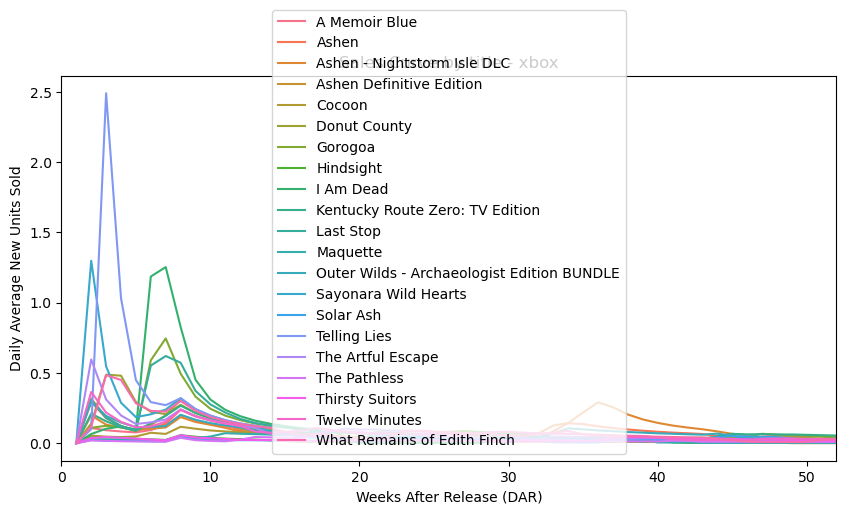

In [32]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

sns.lineplot(data=df_combined, x='Weeks_from_Release', y='daily_delta', hue='product')
# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title(f"Sales Curve by title - {file_name}")
plt.legend(loc="best")
#plt.tight_layout()# Set legend title
plt.xlim(0,52)
plt.show()

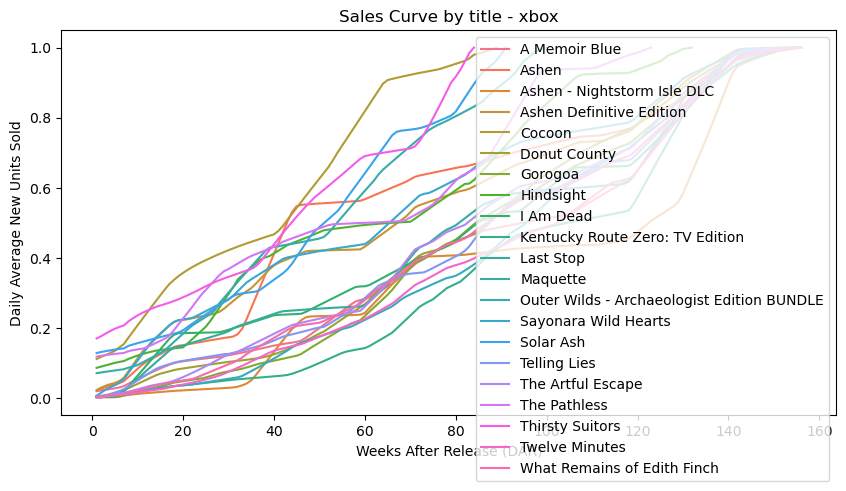

In [33]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

sns.lineplot(data=df_combined, x='Weeks_from_Release', y='prop_of_total', hue='product')
# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title(f"Sales Curve by title - {file_name}")
plt.legend(loc="best")
#plt.tight_layout()# Set legend title
plt.savefig(f"{file_name}.png")
plt.show()

In [34]:
stop

NameError: name 'stop' is not defined

In [ ]:
### Fit the Curve to a model and use this to predict



# Define folder path
folder_path = "/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.csv")

# Read all files into DataFrames and add filename column
dfs = [pd.read_csv(file).assign(Source=os.path.basename(file)) for file in files]




In [ ]:
files

In [ ]:
av_df = pd.concat(dfs, ignore_index=True)


In [ ]:
platforms = av_df.pivot_table(columns='platform', index='Weeks_from_Release', values='daily_delta').reset_index()

In [ ]:
platforms.to_clipboard()

In [ ]:
platforms.columns[1:]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

# Loop through unique platforms and plot each separately
for platform in ['apple', 'epic', 'gog', 'google', 'humble', 'nintendo', 'playstation',
       'steam', 'xbox']:
    pdf = av_df.query("platform == @platform")
    sns.lineplot(data=pdf, x='Weeks_from_Release', y='prop_of_total', label=platform)

# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title("Sales Curve by Platform")
plt.legend(title="Platform", loc="best")  # Set legend title
plt.xlim(0)
plt.grid(True)  # Add grid for readability

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

# Loop through unique platforms and plot each separately
for platform in ['apple', 'epic', 'gog', 'google', 'humble', 'nintendo', 'playstation',
       'steam', 'xbox']:
    pdf = av_df.query("platform == @platform")
    sns.lineplot(data=pdf, x='Weeks_from_Release', y='daily_delta', label=platform)

# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title("Sales Curve by Platform")
plt.legend(title="Platform", loc="best")  # Set legend title
plt.xlim(0,52)
plt.grid(True)  # Add grid for readability

plt.show()